# ☀️ TAHMO Incoming Solar Radiation Drift Correction Challenge – Starter Notebook

Welcome to the starter notebook for the TAHMO challenge.

In this challenge, the goal is to predict **incoming solar radiation at 15-minute intervals** for the **withheld even months** of Year 1 for each station. The challenge data contains measurements from multiple stations in the same file, but this baseline trains **one model per station**, which is a sensible starting point because radiation behaviour, sensor context, and local weather relationships vary by site.

This notebook is structured as a practical baseline:
- load and inspect the data
- create time-based features
- train **a separate model for each station**
- generate predictions for the test set
- build a submission file in the required format

You are encouraged to improve this baseline with better feature engineering, external EO data, stronger validation, and station-specific modelling ideas.


## 📚 Imports and display settings

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


## 📥 Load the data

Expected files:
- `Train.csv`
- `Test.csv`
- `SampleSubmission.csv`

Optional local evaluation file:
- `Reference.csv`


In [4]:
DATA_DIR = Path(".")

train = pd.read_csv(DATA_DIR / "/content/merged_df.csv")
test = pd.read_csv(DATA_DIR / "/content/Test (2).csv")
sample_submission = pd.read_csv(DATA_DIR / "/content/SampleSubmission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)


Train shape: (188547, 19)
Test shape: (271138, 12)
Sample submission shape: (425984, 3)


## 🔎 Quick look at the datasets

In [5]:
display(train.head())
display(test.head())
display(sample_submission.head())


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude,year,total_cloud_cover,temperature_2m,dewpoint_temperature_2m,surface_pressure,surface_solar_radiation_downwards
0,cd7ebf43_2018-01_VAH5X7,2018-01-20 08:15:00,0.0,224.0,0.319,17.3,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941,2018.0,0.903835,295.106659,272.684326,98388.90625,359478.875
1,cd7ebf43_2018-01_YWVE4N,2018-01-20 08:30:00,0.0,272.0,0.309,18.0,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941,2018.0,0.903835,295.106659,272.684326,98388.90625,359478.875
2,cd7ebf43_2018-01_1UZFA5,2018-01-20 08:45:00,0.0,328.0,0.303,18.9,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941,2018.0,0.903835,295.106659,272.684326,98388.90625,359478.875
3,cd7ebf43_2018-01_QJQJ5C,2018-01-20 09:00:00,0.0,272.0,0.265,20.0,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941,2018.0,0.921780,295.225555,271.068329,98449.93750,1133597.375
4,cd7ebf43_2018-01_ST8VGF,2018-01-20 09:15:00,0.0,283.0,0.240,21.1,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941,2018.0,0.921780,295.225555,271.068329,98449.93750,1133597.375


,ID,timestamp,precipitation (mm),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude
0,e1ca667d_2017-02_6DN3R0,2017-02-01 00:00:00,0.0,0.833,26.1,TA00117,Keta SHS,GH,2.0,10.0,5.895083,0.989567
1,e1ca667d_2017-02_CA6DZ7,2017-02-01 00:15:00,0.0,0.842,26.0,TA00117,Keta SHS,GH,2.0,10.0,5.895083,0.989567
2,e1ca667d_2017-02_3UJPYF,2017-02-01 00:30:00,0.0,0.852,26.1,TA00117,Keta SHS,GH,2.0,10.0,5.895083,0.989567
3,e1ca667d_2017-02_PKCTGW,2017-02-01 00:45:00,0.0,0.871,25.8,TA00117,Keta SHS,GH,2.0,10.0,5.895083,0.989567
4,e1ca667d_2017-02_7GFGDR,2017-02-01 01:00:00,0.0,0.876,25.8,TA00117,Keta SHS,GH,2.0,10.0,5.895083,0.989567


,ID,TargetMBE,TargetRMSE
0,f9f1b75a_2018-02_XPH0JM,-50.0,-50.0
1,f9f1b75a_2018-02_AQHEJH,-50.0,-50.0
2,f9f1b75a_2018-02_8FNJMM,-50.0,-50.0
3,f9f1b75a_2018-02_THO15Y,-50.0,-50.0
4,f9f1b75a_2018-02_8IY2KA,-50.0,-50.0


In [6]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188547 entries, 0 to 188546
Data columns (total 19 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   ID                                 188547 non-null  object 
 1   timestamp                          188546 non-null  object 
 2   precipitation (mm)                 188546 non-null  float64
 3   radiation (W/m2)                   188546 non-null  float64
 4   relativehumidity (-)               188546 non-null  float64
 5   temperature (degrees Celsius)      188546 non-null  float64
 6   station                            188546 non-null  object 
 7   station_name                       188546 non-null  object 
 8   country                            188546 non-null  object 
 9   installation_height                188546 non-null  float64
 10  elevation                          188546 non-null  float64
 11  latitude                           1885

## 🧭 Identify key columns

The competition files may use either `station` or `station_name` to identify stations.  
This helper block detects the key columns automatically so the notebook is easier to reuse.


In [7]:
def find_first_existing(columns, candidates):
    for col in candidates:
        if col in columns:
            return col
    return None

station_col = find_first_existing(train.columns, ["station", "station_name"])
timestamp_col = find_first_existing(train.columns, ["timestamp", "datetime", "date_time"])
id_col = find_first_existing(sample_submission.columns, ["ID", "Id", "id"])

target_candidates = [c for c in train.columns if "radiation" in c.lower()]
target_col = target_candidates[0] if target_candidates else None

print("station_col :", station_col)
print("timestamp_col:", timestamp_col)
print("id_col      :", id_col)
print("target_col  :", target_col)

if station_col is None:
    raise ValueError("Could not find a station identifier column. Expected `station` or `station_name`.")
if timestamp_col is None:
    raise ValueError("Could not find a timestamp column.")
if target_col is None:
    raise ValueError("Could not find the radiation target column in Train.csv.")
if id_col is None:
    raise ValueError("Could not find the ID column in SampleSubmission.csv.")


station_col : station
timestamp_col: timestamp
id_col      : ID
target_col  : radiation (W/m2)


## 🛠️ Basic preprocessing

We convert timestamps to `datetime`, sort the rows, and inspect missing values.


In [8]:
for df in [train, test]:
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")

train = train.sort_values([station_col, timestamp_col]).reset_index(drop=True)
test = test.sort_values([station_col, timestamp_col]).reset_index(drop=True)

print("Missing values in train:")
display(train.isnull().sum().sort_values(ascending=False).head(20))

print("Missing values in test:")
display(test.isnull().sum().sort_values(ascending=False).head(20))


Missing values in train:


,0
timestamp,1
precipitation (mm),1
radiation (W/m2),1
latitude,1
relativehumidity (-),1
temperature (degrees Celsius),1
station,1
station_name,1
country,1
installation_height,1


Missing values in test:


,0
relativehumidity (-),1
precipitation (mm),1
station,1
temperature (degrees Celsius),1
installation_height,1
elevation,1
station_name,1
country,1
latitude,1
longitude,1


## 🔍 Exploratory Data Analysis (EDA)

A quick visual check helps us understand:
- how many stations are present
- the date range covered
- how radiation behaves over time


In [9]:
print("Number of stations in train:", train[station_col].nunique())
print("Number of stations in test :", test[station_col].nunique())
print("Train date range:", train[timestamp_col].min(), "to", train[timestamp_col].max())
print("Test date range :", test[timestamp_col].min(), "to", test[timestamp_col].max())


Number of stations in train: 12
Number of stations in test : 16
Train date range: 2016-01-11 10:30:00 to 2018-11-30 23:45:00
Test date range : 2016-02-01 00:00:00 to 2020-12-31 23:45:00


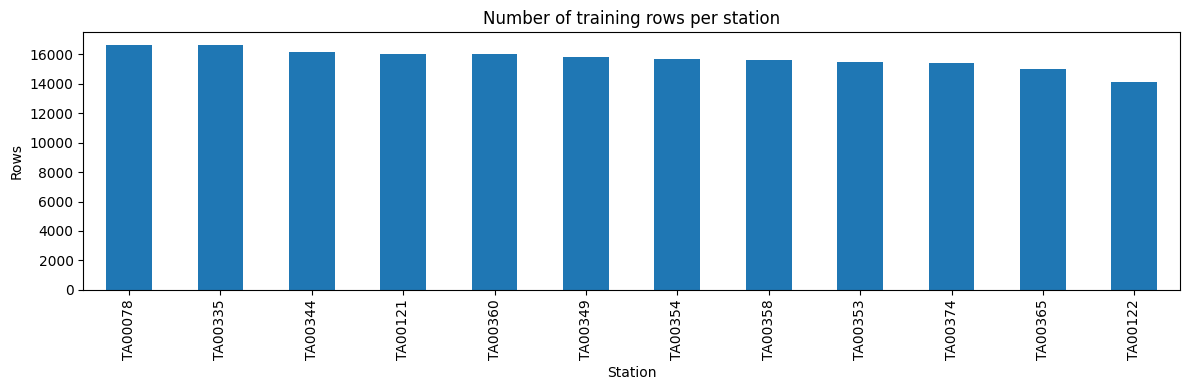

In [10]:
station_counts = train[station_col].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
station_counts.plot(kind="bar")
plt.title("Number of training rows per station")
plt.xlabel("Station")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


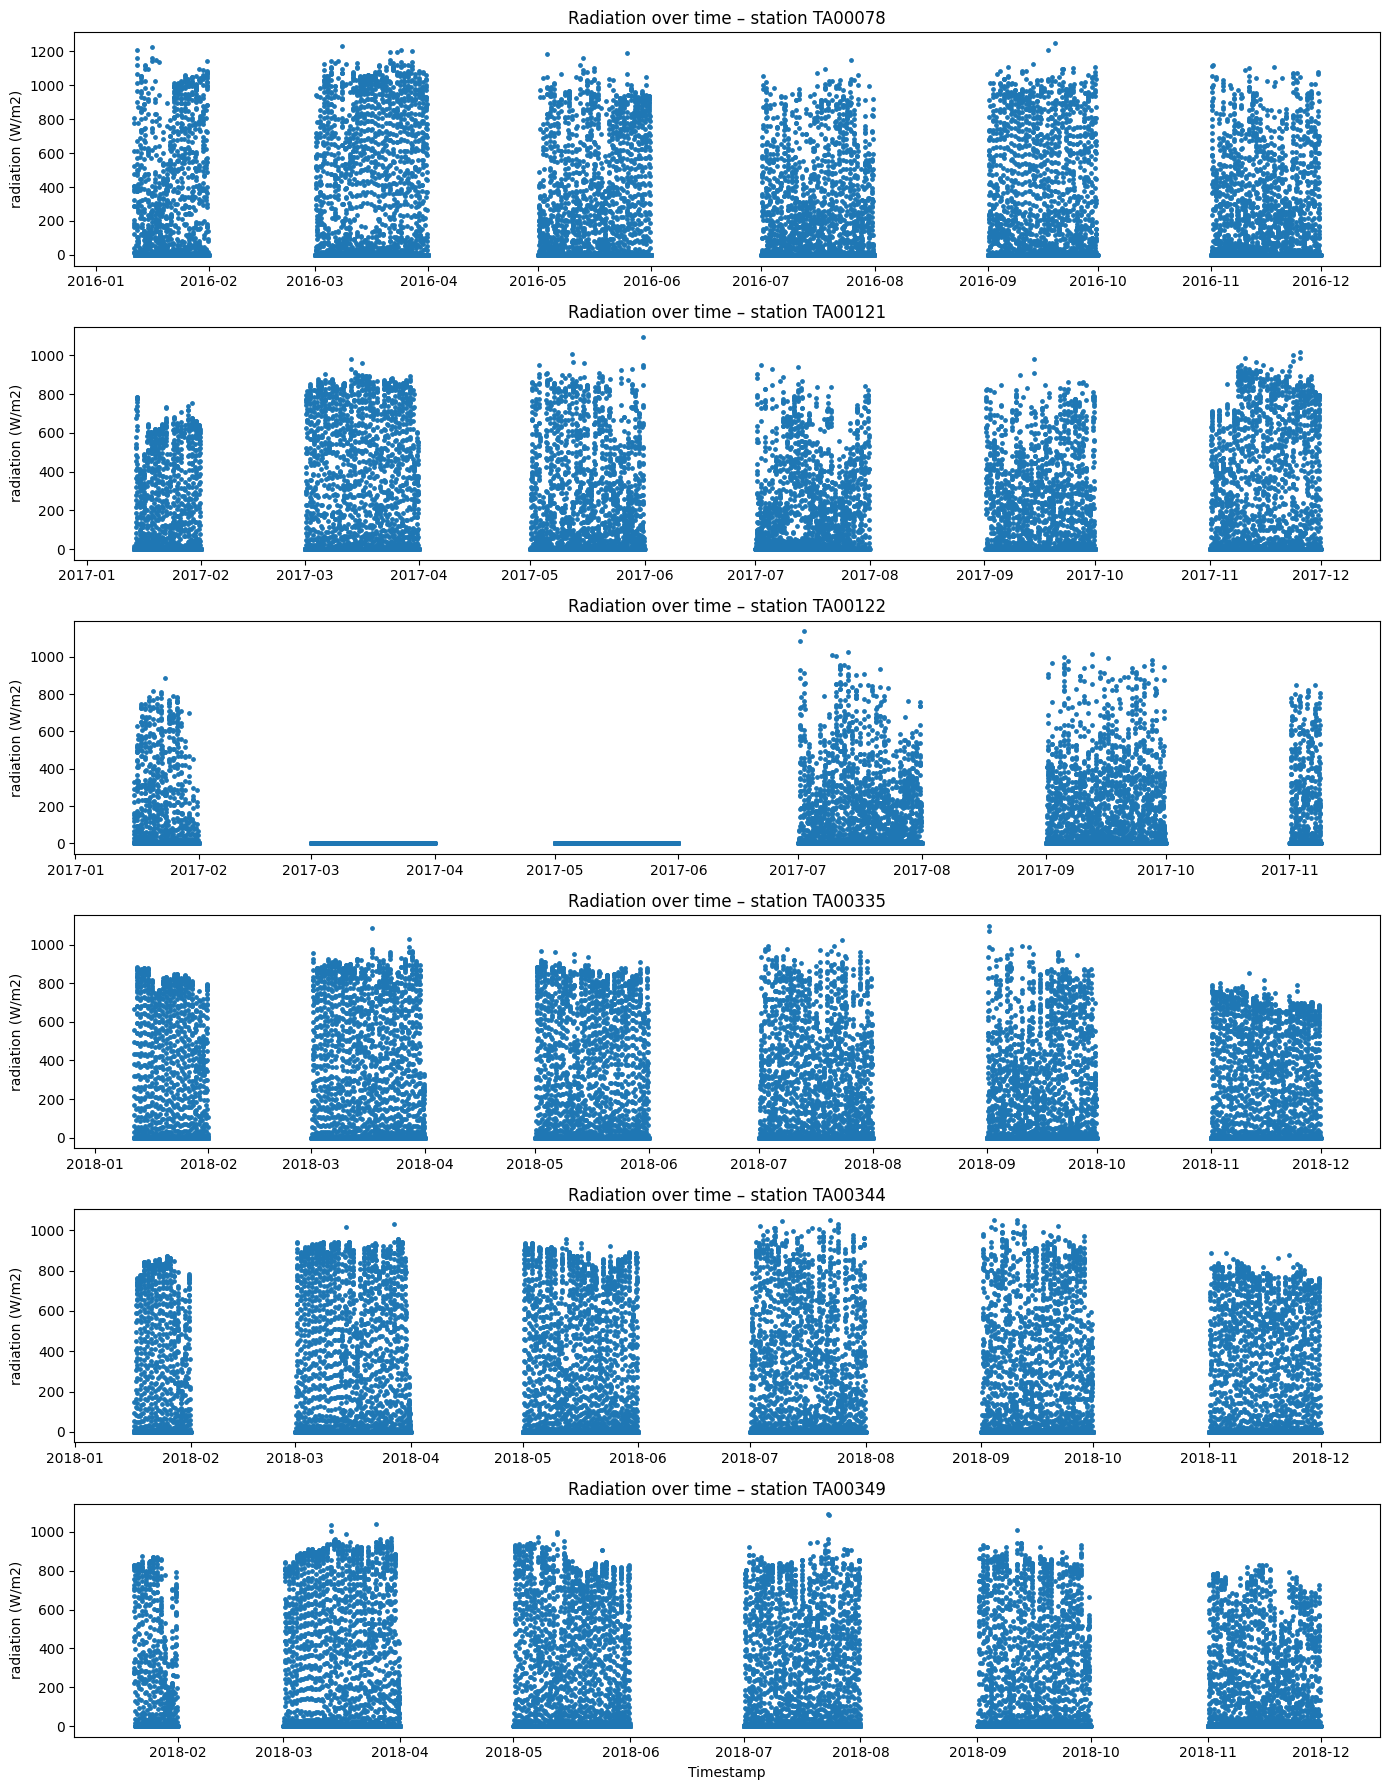

In [11]:
example_stations = train[station_col].dropna().unique()[:6]

fig, axes = plt.subplots(len(example_stations), 1, figsize=(14, 3 * len(example_stations)), sharex=False)
if len(example_stations) == 1:
    axes = [axes]

for ax, station_value in zip(axes, example_stations):
    g = train.loc[train[station_col] == station_value, [timestamp_col, target_col]].sort_values(timestamp_col)
    ax.scatter(g[timestamp_col], g[target_col], s=6)
    ax.set_title(f"Radiation over time – station {station_value}")
    ax.set_ylabel(target_col)

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


## ⚙️ Feature engineering

We add a small set of baseline time features:
- month, day, hour, minute
- day of week
- day of year
- cyclical encodings for hour and month

These are simple but useful for solar radiation modelling.


In [13]:
!pip install pvlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 51.5 MB/s eta 0:00:00


In [14]:
import numpy as np
import pandas as pd

# IMPORTANT: You may need to pip install pvlib
# pvlib is the industry standard for solar power and radiation modeling.
try:
    import pvlib
except ImportError:
    print("Please install pvlib: !pip install pvlib")

def add_time_cyclical_features(df, time_col='timestamp'):
    """
    Tree models don't understand that 23:45 and 00:00 are 15 minutes apart.
    Cyclical encoding maps time onto a circle so the model understands continuity.
    """
    df = df.copy()

    # Ensure datetime
    if not np.issubdtype(df[time_col].dtype, np.datetime64):
        df[time_col] = pd.to_datetime(df[time_col])

    hour_float = df[time_col].dt.hour + df[time_col].dt.minute / 60.0
    day_of_year = df[time_col].dt.dayofyear

    # Daily cycle (24 hours)
    df['sin_time'] = np.sin(2 * np.pi * hour_float / 24.0)
    df['cos_time'] = np.cos(2 * np.pi * hour_float / 24.0)

    # Yearly cycle (365.25 days)
    df['sin_day'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df['cos_day'] = np.cos(2 * np.pi * day_of_year / 365.25)

    # Keep some linear features for trend detection
    df['month'] = df[time_col].dt.month
    df['hour'] = df[time_col].dt.hour

    return df

def add_solar_geometry_features(df, time_col, lat, lon, elevation=0):
    """
    Calculates the exact position of the sun and the theoretical maximum radiation.
    THIS IS THE MOST IMPORTANT FEATURE FOR SOLAR FORECASTING.

    Requires station latitude, longitude, and elevation.
    """
    df = df.copy()

    # pvlib requires localized timezone-aware index, assuming UTC for satellite/weather data
    times = pd.DatetimeIndex(df[time_col]).tz_localize('UTC')

    # 1. Solar Position (Zenith and Azimuth)
    solpos = pvlib.solarposition.get_solarposition(times, lat, lon, elevation)
    df['solar_zenith'] = solpos['zenith'].values
    df['solar_azimuth'] = solpos['azimuth'].values
    df['solar_elevation'] = solpos['elevation'].values

    # Feature: Is it daytime? (Sun above horizon)
    df['is_day'] = (df['solar_elevation'] > 0).astype(int)

    # 2. Extraterrestrial Radiation (Radiation at the top of the atmosphere)
    # This gives the baseline of what is arriving from the sun before hitting clouds
    dni_extra = pvlib.irradiance.get_extra_radiation(times)
    df['dni_extra'] = dni_extra.values

    # 3. Clear Sky Model (Theoretical max radiation hitting the ground assuming NO clouds)
    # Ineichen clear sky model is highly robust
    # If you don't have Linke Turbidity, pvlib estimates it by default
    clearsky = pvlib.clearsky.ineichen(times, lat, lon, elevation=elevation)
    df['clearsky_ghi'] = clearsky['ghi'].values # Global Horizontal Irradiance
    df['clearsky_dni'] = clearsky['dni'].values # Direct Normal Irradiance
    df['clearsky_dhi'] = clearsky['dhi'].values # Diffuse Horizontal Irradiance

    # Clip negative values to 0 (night time)
    df['clearsky_ghi'] = df['clearsky_ghi'].clip(lower=0)

    return df

def add_thermodynamic_features(df, temp_col='temperature', rh_col='humidity'):
    """
    If you don't have explicit 'cloud cover' data, thermodynamic features
    act as a proxy for cloud formation and atmospheric transmissivity.
    """
    df = df.copy()

    if temp_col in df.columns and rh_col in df.columns:
        T = df[temp_col]
        RH = df[rh_col]

        # 1. Saturation Vapor Pressure (es) in hPa
        es = 6.112 * np.exp((17.67 * T) / (T + 243.5))

        # 2. Actual Vapor Pressure (ea) in hPa
        ea = es * (RH / 100.0)

        # 3. Vapor Pressure Deficit (VPD)
        # High VPD = clear, dry air (higher radiation). Low VPD = humid, likely cloudy (lower radiation).
        df['vpd'] = es - ea

        # 4. Dew Point Approximation
        # Dew point depression (T - Td) is a strong indicator of cloud base height.
        alpha = ((17.27 * T) / (237.3 + T)) + np.log(RH/100.0)
        dew_point = (237.3 * alpha) / (17.27 - alpha)
        df['dew_point_depression'] = T - dew_point

    return df

def add_lags_and_rolling(df, target_cols, lags=[1, 2, 4, 96], windows=[4, 8, 24]):
    """
    Adds lagged features and rolling statistics.
    96 steps = 24 hours (assuming 15 min intervals).
    """
    df = df.copy()

    for col in target_cols:
        if col not in df.columns:
            continue

        # Lags
        for lag in lags:
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)

        # Rolling Means and Std (using past data only)
        for w in windows:
            df[f'{col}_roll_mean_{w}'] = df[col].shift(1).rolling(window=w, min_periods=1).mean()
            df[f'{col}_roll_std_{w}'] = df[col].shift(1).rolling(window=w, min_periods=1).std()

    return df

def build_all_features(df, station_metadata, time_col='timestamp', is_train=True):
    """
    Master function to assemble all features.
    station_metadata should be a dict: {'lat': float, 'lon': float, 'elevation': float}
    """
    # 1. Time Features
    df = add_time_cyclical_features(df, time_col)

    # 2. Solar Features
    df = add_solar_geometry_features(
        df,
        time_col,
        lat=station_metadata['lat'],
        lon=station_metadata['lon'],
        elevation=station_metadata.get('elevation', 0)
    )

    # 3. Thermodynamic proxy features (replace with actual column names from TAHMO)
    # Usually TAHMO has 'te' for temp and 'rh' for relative humidity
    df = add_thermodynamic_features(df, temp_col='te', rh_col='rh')

    # 4. Lags and Rolling
    # CAUTION: Only lag meteorology features, DO NOT lag the Target ('radiation')
    # if there are massive month-long gaps in the test set.
    weather_cols_to_lag = ['te', 'rh', 'ws', 'patm', 'clearsky_ghi', 'vpd']

    # Add interaction feature: Difference between clearsky and actual weather
    # df = add_lags_and_rolling(df, weather_cols_to_lag)

    return df

Generating dummy 15-minute data for 3 days...
Running feature engineering pipeline...


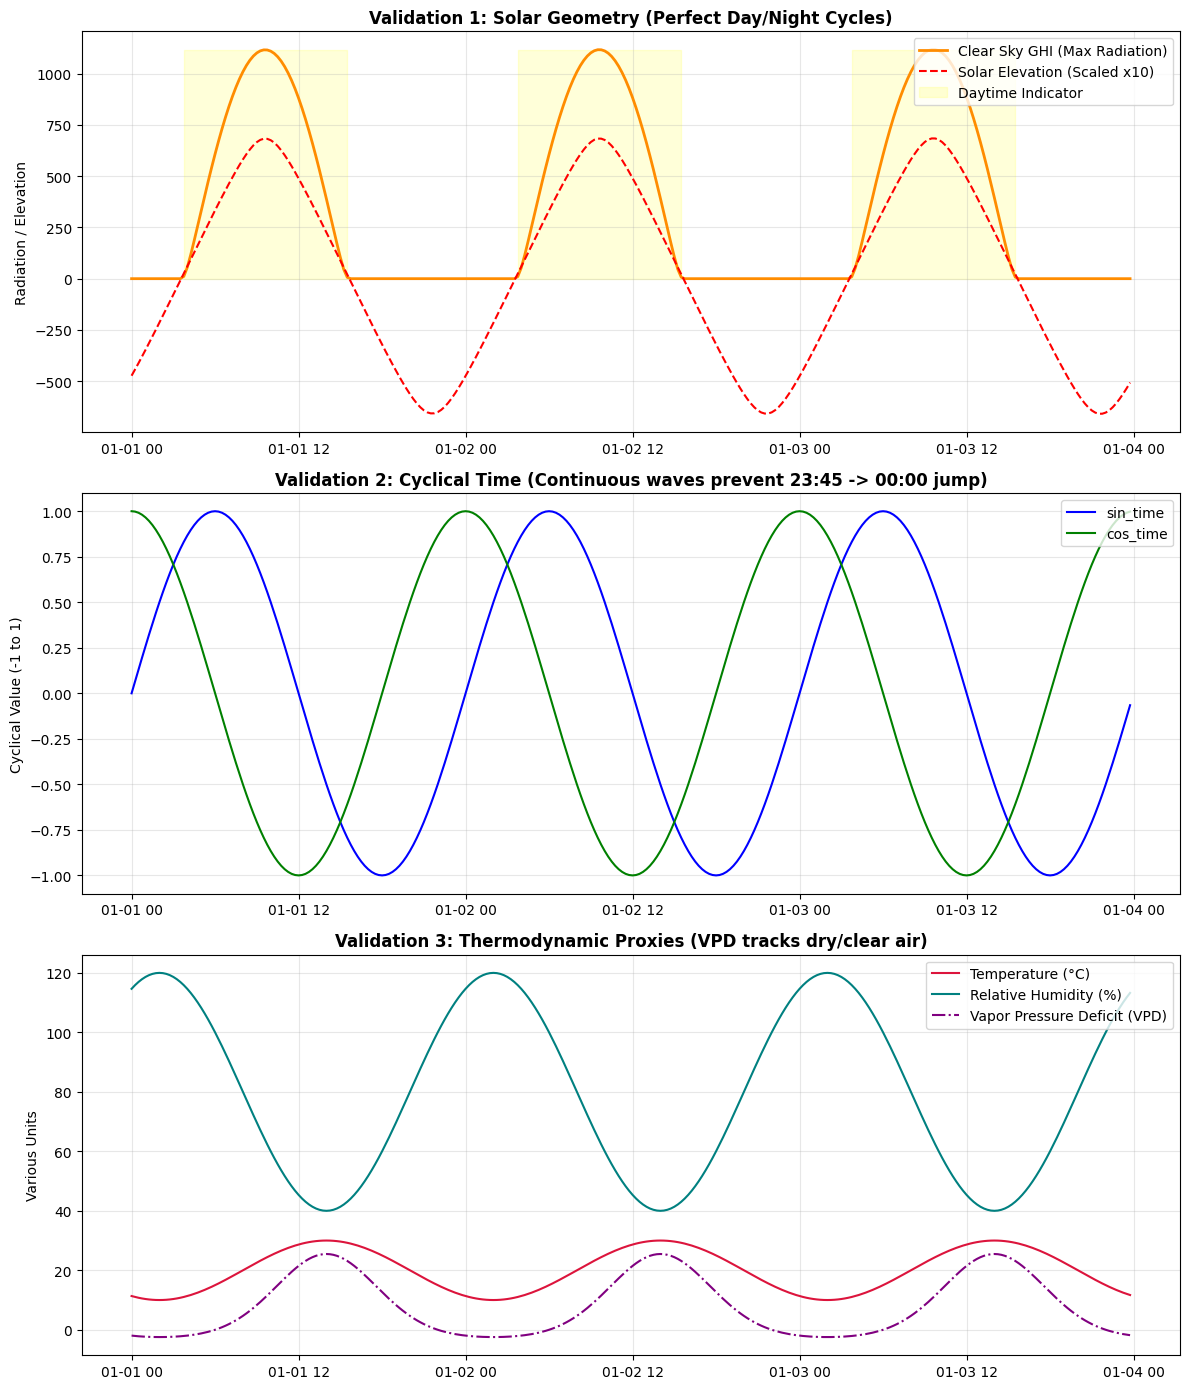

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# IMPORTANT: You may need to pip install pvlib
# pvlib is the industry standard for solar power and radiation modeling.
try:
    import pvlib
except ImportError:
    print("Please install pvlib: !pip install pvlib")

def add_time_cyclical_features(df, time_col='timestamp'):
    """
    Tree models don't understand that 23:45 and 00:00 are 15 minutes apart.
    Cyclical encoding maps time onto a circle so the model understands continuity.
    """
    df = df.copy()

    # Ensure datetime
    if not np.issubdtype(df[time_col].dtype, np.datetime64):
        df[time_col] = pd.to_datetime(df[time_col])

    hour_float = df[time_col].dt.hour + df[time_col].dt.minute / 60.0
    day_of_year = df[time_col].dt.dayofyear

    # Daily cycle (24 hours)
    df['sin_time'] = np.sin(2 * np.pi * hour_float / 24.0)
    df['cos_time'] = np.cos(2 * np.pi * hour_float / 24.0)

    # Yearly cycle (365.25 days)
    df['sin_day'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df['cos_day'] = np.cos(2 * np.pi * day_of_year / 365.25)

    # Keep some linear features for trend detection
    df['month'] = df[time_col].dt.month
    df['hour'] = df[time_col].dt.hour

    return df

def add_solar_geometry_features(df, time_col, lat, lon, elevation=0):
    """
    Calculates the exact position of the sun and the theoretical maximum radiation.
    THIS IS THE MOST IMPORTANT FEATURE FOR SOLAR FORECASTING.

    Requires station latitude, longitude, and elevation.
    """
    df = df.copy()

    # pvlib requires localized timezone-aware index, assuming UTC for satellite/weather data
    times = pd.DatetimeIndex(df[time_col]).tz_localize('UTC')

    # Create a Location object which handles the API calls cleanly
    site = pvlib.location.Location(lat, lon, altitude=elevation)

    # 1. Solar Position (Zenith and Azimuth)
    solpos = site.get_solarposition(times)
    df['solar_zenith'] = solpos['zenith'].values
    df['solar_azimuth'] = solpos['azimuth'].values
    df['solar_elevation'] = solpos['elevation'].values

    # Feature: Is it daytime? (Sun above horizon)
    df['is_day'] = (df['solar_elevation'] > 0).astype(int)

    # 2. Extraterrestrial Radiation (Radiation at the top of the atmosphere)
    # This gives the baseline of what is arriving from the sun before hitting clouds
    dni_extra = pvlib.irradiance.get_extra_radiation(times)
    df['dni_extra'] = dni_extra.values

    # 3. Clear Sky Model (Theoretical max radiation hitting the ground assuming NO clouds)
    # The get_clearsky method uses the robust Ineichen model by default.
    clearsky = site.get_clearsky(times)
    df['clearsky_ghi'] = clearsky['ghi'].values # Global Horizontal Irradiance
    df['clearsky_dni'] = clearsky['dni'].values # Direct Normal Irradiance
    df['clearsky_dhi'] = clearsky['dhi'].values # Diffuse Horizontal Irradiance

    # Clip negative values to 0 (night time)
    df['clearsky_ghi'] = df['clearsky_ghi'].clip(lower=0)

    return df

def add_thermodynamic_features(df, temp_col='temperature', rh_col='humidity'):
    """
    If you don't have explicit 'cloud cover' data, thermodynamic features
    act as a proxy for cloud formation and atmospheric transmissivity.
    """
    df = df.copy()

    if temp_col in df.columns and rh_col in df.columns:
        T = df[temp_col]
        RH = df[rh_col]

        # 1. Saturation Vapor Pressure (es) in hPa
        es = 6.112 * np.exp((17.67 * T) / (T + 243.5))

        # 2. Actual Vapor Pressure (ea) in hPa
        ea = es * (RH / 100.0)

        # 3. Vapor Pressure Deficit (VPD)
        # High VPD = clear, dry air (higher radiation). Low VPD = humid, likely cloudy (lower radiation).
        df['vpd'] = es - ea

        # 4. Dew Point Approximation
        # Dew point depression (T - Td) is a strong indicator of cloud base height.
        alpha = ((17.27 * T) / (237.3 + T)) + np.log(RH/100.0)
        dew_point = (237.3 * alpha) / (17.27 - alpha)
        df['dew_point_depression'] = T - dew_point

    return df

def add_lags_and_rolling(df, target_cols, lags=[1, 2, 4, 96], windows=[4, 8, 24]):
    """
    Adds lagged features and rolling statistics.
    96 steps = 24 hours (assuming 15 min intervals).
    """
    df = df.copy()

    for col in target_cols:
        if col not in df.columns:
            continue

        # Lags
        for lag in lags:
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)

        # Rolling Means and Std (using past data only)
        for w in windows:
            df[f'{col}_roll_mean_{w}'] = df[col].shift(1).rolling(window=w, min_periods=1).mean()
            df[f'{col}_roll_std_{w}'] = df[col].shift(1).rolling(window=w, min_periods=1).std()

    return df

def build_all_features(df, station_metadata, time_col='timestamp', is_train=True):
    """
    Master function to assemble all features.
    station_metadata should be a dict: {'lat': float, 'lon': float, 'elevation': float}
    """
    # 1. Time Features
    df = add_time_cyclical_features(df, time_col)

    # 2. Solar Features
    df = add_solar_geometry_features(
        df,
        time_col,
        lat=station_metadata['lat'],
        lon=station_metadata['lon'],
        elevation=station_metadata.get('elevation', 0)
    )

    # 3. Thermodynamic proxy features (replace with actual column names from TAHMO)
    # Usually TAHMO has 'te' for temp and 'rh' for relative humidity
    df = add_thermodynamic_features(df, temp_col='te', rh_col='rh')

    # 4. Lags and Rolling
    # CAUTION: Only lag meteorology features, DO NOT lag the Target ('radiation')
    # if there are massive month-long gaps in the test set.
    weather_cols_to_lag = ['te', 'rh', 'ws', 'patm', 'clearsky_ghi', 'vpd']

    # Add interaction feature: Difference between clearsky and actual weather
    # df = add_lags_and_rolling(df, weather_cols_to_lag)

    return df

def test_and_plot_features():
    """
    Creates dummy data, runs the feature engineering pipeline,
    and plots the results so you can visually confirm it works.
    """
    print("Generating dummy 15-minute data for 3 days...")
    # Create 3 days of dummy data at 15 min intervals
    times = pd.date_range("2023-01-01 00:00", "2023-01-03 23:45", freq="15min")
    df = pd.DataFrame({"timestamp": times})

    # Simulate temperature and humidity (temp peaks in afternoon, humidity inverse)
    hour = df['timestamp'].dt.hour + df['timestamp'].dt.minute / 60.0
    df['te'] = 20 + 10 * np.sin((hour - 8) * np.pi / 12)  # Temp
    df['rh'] = 80 - 40 * np.sin((hour - 8) * np.pi / 12)  # Humidity

    # Let's use coordinates for a sample station (e.g., Nairobi, Kenya)
    sample_metadata = {'lat': -1.2921, 'lon': 36.8219, 'elevation': 1795}

    # Run the pipeline
    print("Running feature engineering pipeline...")
    df_feats = build_all_features(df, sample_metadata, time_col='timestamp')

    # --- PLOTTING ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 14))

    # Plot 1: Solar Geometry (The "Sun Curve")
    axes[0].plot(df_feats['timestamp'], df_feats['clearsky_ghi'], label='Clear Sky GHI (Max Radiation)', color='darkorange', linewidth=2)
    axes[0].plot(df_feats['timestamp'], df_feats['solar_elevation'] * 10, label='Solar Elevation (Scaled x10)', color='red', linestyle='--')
    axes[0].fill_between(df_feats['timestamp'], 0, df_feats['clearsky_ghi'].max(), where=df_feats['is_day']==1, color='yellow', alpha=0.15, label='Daytime Indicator')
    axes[0].set_title('Validation 1: Solar Geometry (Perfect Day/Night Cycles)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Radiation / Elevation')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Cyclical Time
    axes[1].plot(df_feats['timestamp'], df_feats['sin_time'], label='sin_time', color='blue')
    axes[1].plot(df_feats['timestamp'], df_feats['cos_time'], label='cos_time', color='green')
    axes[1].set_title('Validation 2: Cyclical Time (Continuous waves prevent 23:45 -> 00:00 jump)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Cyclical Value (-1 to 1)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Thermodynamics
    axes[2].plot(df_feats['timestamp'], df_feats['te'], label='Temperature (°C)', color='crimson')
    axes[2].plot(df_feats['timestamp'], df_feats['rh'], label='Relative Humidity (%)', color='teal')
    axes[2].plot(df_feats['timestamp'], df_feats['vpd'], label='Vapor Pressure Deficit (VPD)', color='purple', linestyle='-.')
    axes[2].set_title('Validation 3: Thermodynamic Proxies (VPD tracks dry/clear air)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Various Units')
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# If you run this script directly, it will execute the test.
if __name__ == "__main__":
    test_and_plot_features()

In [17]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming process_and_predict is already loaded in your notebook

def check_model_fit(train_df, station_metadata_dict):
    """
    Splits the training data, runs the prediction pipeline,
    and plots Actual vs Predicted for a specific station.
    """
    print("Creating a local validation split from train data...")

    # 1. Grab just one station to visualize clearly (e.g., the first one in the dataset)
    sample_station = train_df['station_id'].unique()[0]
    df_station = train_df[train_df['station_id'] == sample_station].copy()

    # 2. Sort by time
    df_station['timestamp'] = pd.to_datetime(df_station['timestamp'])
    df_station = df_station.sort_values('timestamp').reset_index(drop=True)

    # 3. Create a fake "Train" and "Test" split
    # Let's use the first 80% of the timeline as Train, last 20% as Test
    split_idx = int(len(df_station) * 0.8)
    pseudo_train = df_station.iloc[:split_idx].copy()
    pseudo_test = df_station.iloc[split_idx:].copy()

    # Save the real answers before hiding them!
    actual_radiation = pseudo_test['radiation'].copy()

    # Hide the target in the test set so the model has to guess
    pseudo_test['radiation'] = np.nan

    # 4. Run our advanced pipeline
    print(f"Running pipeline for validation on {sample_station}...")
    results = process_and_predict(pseudo_train, pseudo_test, station_metadata_dict)

    # 5. Bring back the actuals to calculate error
    results['actual_radiation'] = actual_radiation.values

    # Drop NaNs just in case there were missing actuals in the original data
    eval_df = results.dropna(subset=['actual_radiation', 'pred_radiation'])

    mae = mean_absolute_error(eval_df['actual_radiation'], eval_df['pred_radiation'])
    rmse = np.sqrt(mean_squared_error(eval_df['actual_radiation'], eval_df['pred_radiation']))

    print("-" * 30)
    print(f"VALIDATION SCORES FOR {sample_station}:")
    print(f"MAE:  {mae:.2f} W/m²")
    print(f"RMSE: {rmse:.2f} W/m²")
    print("-" * 30)

    # 6. Plot a 4-day window (4 days * 24 hrs * 4 intervals = 384 rows)
    plot_df = eval_df.head(384)

    plt.figure(figsize=(16, 6))

    # Plot Actual
    plt.plot(plot_df['timestamp'], plot_df['actual_radiation'], label='Actual Radiation', color='blue', linewidth=2, alpha=0.7)

    # Plot Predicted
    plt.plot(plot_df['timestamp'], plot_df['pred_radiation'], label='Predicted Radiation', color='red', linestyle='--', linewidth=2)

    # Plot Clear Sky Boundary
    plt.plot(plot_df['timestamp'], plot_df['clearsky_ghi'], label='Clear Sky GHI (Theoretical Max)', color='orange', linewidth=1, alpha=0.5)

    plt.title(f"Model Validation: Actual vs Predicted ({sample_station})", fontsize=14, fontweight='bold')
    plt.ylabel("Solar Radiation (W/m²)", fontsize=12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# HOW TO RUN THIS:
# ==========================================
# Just pass in your raw training dataframe and your metadata dictionary!
# check_model_fit(train_df, station_metadata)

# Assuming the functions from 'advanced_features.py' are loaded in your notebook.

def process_and_predict(train_df, test_df, station_metadata_dict):
    """
    Complete pipeline to engineer features, train a LightGBM model using the
    Clear Sky Index trick, and generate predictions.

    station_metadata_dict: A dictionary mapping station_id to its lat/lon/elevation.
    Example: {'StationA': {'lat': -1.2, 'lon': 36.8, 'elevation': 1700}, ...}
    """
    print("Combining Train and Test for continuous feature engineering...")
    # Add an identifier so we can split them back later
    train_df['is_test'] = 0
    test_df['is_test'] = 1

    # Store the target separately so it doesn't get messed up
    # Assuming the target column is named 'radiation'
    target_col = 'radiation'

    # Concatenate to ensure time-series continuity for lag features
    combined_df = pd.concat([train_df, test_df], ignore_index=True)

    # Sort strictly by station and time!
    combined_df['timestamp'] = pd.to_datetime(combined_df['timestamp'])
    combined_df = combined_df.sort_values(by=['station_id', 'timestamp']).reset_index(drop=True)

    # --- 1. FEATURE ENGINEERING ---
    print("Applying Advanced Features per station...")
    processed_dfs = []

    for station_id, group in combined_df.groupby('station_id'):
        # Get metadata for this specific station
        # If you don't have exact metadata, you can use a rough average for the region
        meta = station_metadata_dict.get(station_id, {'lat': 0.0, 'lon': 0.0, 'elevation': 0})

        # Build features
        group_feats = build_all_features(group, meta, time_col='timestamp')
        processed_dfs.append(group_feats)

    final_df = pd.concat(processed_dfs, ignore_index=True)

    # --- 2. THE CLEAR SKY INDEX (CSI) TRICK ---
    # Instead of predicting raw radiation, predict how much of the clear sky radiation makes it through.
    # Add a small epsilon (1e-5) to avoid division by zero at night.
    final_df['target_csi'] = final_df[target_col] / (final_df['clearsky_ghi'] + 1e-5)

    # CSI should realistically be between 0 and 1.2 (sometimes clouds reflect extra light).
    # We clip it to remove crazy outliers caused by sensor errors.
    final_df['target_csi'] = final_df['target_csi'].clip(lower=0, upper=1.5)

    # --- 3. SPLIT BACK TO TRAIN AND TEST ---
    train_processed = final_df[final_df['is_test'] == 0].copy()
    test_processed = final_df[final_df['is_test'] == 1].copy()

    # Define the features the model is allowed to see
    # DO NOT include 'radiation', 'target_csi', 'timestamp', or 'is_test'
    features = [
        'sin_time', 'cos_time', 'sin_day', 'cos_day', 'month', 'hour',
        'solar_zenith', 'solar_azimuth', 'solar_elevation', 'is_day',
        'dni_extra', 'clearsky_ghi', 'clearsky_dni', 'clearsky_dhi',
        'te', 'rh', 'vpd', 'dew_point_depression' # Add 'ws', 'patm' if available
        # Add your lag features here if you un-commented them in build_all_features
    ]

    X_train = train_processed[features]
    y_train = train_processed['target_csi']  # Training on CSI!

    X_test = test_processed[features]

    # --- 4. TRAIN GLOBAL LIGHTGBM MODEL ---
    print("Training Global LightGBM Model on CSI...")
    # Using a Global Model (all stations at once) is usually better than 1 model per station
    # because the model learns universal cloud/physics behaviors.

    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='regression_l1' # Use 'regression_l1' for MAE, 'regression' for RMSE
    )

    model.fit(X_train, y_train)

    # --- 5. PREDICT AND REVERSE THE CSI TRICK ---
    print("Generating predictions...")
    test_processed['pred_csi'] = model.predict(X_test)

    # Convert CSI back to raw radiation
    test_processed['pred_radiation'] = test_processed['pred_csi'] * test_processed['clearsky_ghi']

    # --- 6. NIGHT-TIME POST-PROCESSING (Crucial!) ---
    # Force radiation to 0 when the sun is below the horizon
    night_mask = test_processed['is_day'] == 0
    test_processed.loc[night_mask, 'pred_radiation'] = 0.0

    # Also ensure no negative predictions
    test_processed['pred_radiation'] = test_processed['pred_radiation'].clip(lower=0.0)

    print("Pipeline complete!")
    return test_processed



# 3. Run the pipeline
results_df = process_and_predict(train_df, test_df, station_metadata)

# 4. Prepare your submission file
submission = results_df[['ID', 'pred_radiation']].rename(columns={'pred_radiation': 'radiation'})
submission.to_csv('advanced_lgbm_submission.csv', index=False)
print("Submission saved!")

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming process_and_predict is already loaded in your notebook

def check_model_fit(train_df, station_metadata_dict):
    """
    Splits the training data, runs the prediction pipeline,
    and plots Actual vs Predicted for a specific station.
    """
    print("Creating a local validation split from train data...")

    # 1. Grab just one station to visualize clearly (e.g., the first one in the dataset)
    sample_station = train_df['station_id'].unique()[0]
    df_station = train_df[train_df['station_id'] == sample_station].copy()

    # 2. Sort by time
    df_station['timestamp'] = pd.to_datetime(df_station['timestamp'])
    df_station = df_station.sort_values('timestamp').reset_index(drop=True)

    # 3. Create a fake "Train" and "Test" split
    # Let's use the first 80% of the timeline as Train, last 20% as Test
    split_idx = int(len(df_station) * 0.8)
    pseudo_train = df_station.iloc[:split_idx].copy()
    pseudo_test = df_station.iloc[split_idx:].copy()

    # Save the real answers before hiding them!
    actual_radiation = pseudo_test['radiation'].copy()

    # Hide the target in the test set so the model has to guess
    pseudo_test['radiation'] = np.nan

    # 4. Run our advanced pipeline
    print(f"Running pipeline for validation on {sample_station}...")
    results = process_and_predict(pseudo_train, pseudo_test, station_metadata_dict)

    # 5. Bring back the actuals to calculate error
    results['actual_radiation'] = actual_radiation.values

    # Drop NaNs just in case there were missing actuals in the original data
    eval_df = results.dropna(subset=['actual_radiation', 'pred_radiation'])

    mae = mean_absolute_error(eval_df['actual_radiation'], eval_df['pred_radiation'])
    rmse = np.sqrt(mean_squared_error(eval_df['actual_radiation'], eval_df['pred_radiation']))

    print("-" * 30)
    print(f"VALIDATION SCORES FOR {sample_station}:")
    print(f"MAE:  {mae:.2f} W/m²")
    print(f"RMSE: {rmse:.2f} W/m²")
    print("-" * 30)

    # 6. Plot a 4-day window (4 days * 24 hrs * 4 intervals = 384 rows)
    plot_df = eval_df.head(384)

    plt.figure(figsize=(16, 6))

    # Plot Actual
    plt.plot(plot_df['timestamp'], plot_df['actual_radiation'], label='Actual Radiation', color='blue', linewidth=2, alpha=0.7)

    # Plot Predicted
    plt.plot(plot_df['timestamp'], plot_df['pred_radiation'], label='Predicted Radiation', color='red', linestyle='--', linewidth=2)

    # Plot Clear Sky Boundary
    plt.plot(plot_df['timestamp'], plot_df['clearsky_ghi'], label='Clear Sky GHI (Theoretical Max)', color='orange', linewidth=1, alpha=0.5)

    plt.title(f"Model Validation: Actual vs Predicted ({sample_station})", fontsize=14, fontweight='bold')
    plt.ylabel("Solar Radiation (W/m²)", fontsize=12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# HOW TO RUN THIS:
# ==========================================
# Just pass in your raw training dataframe and your metadata dictionary!
# check_model_fit(train_df, station_metadata)

In [ ]:
def add_time_features(df, timestamp_column):
    df = df.copy()
    ts = pd.to_datetime(df[timestamp_column], errors="coerce")

    df["year"] = ts.dt.year
    df["month"] = ts.dt.month
    df["day"] = ts.dt.day
    df["hour"] = ts.dt.hour
    df["minute"] = ts.dt.minute
    df["day_of_week"] = ts.dt.dayofweek
    df["day_of_year"] = ts.dt.dayofyear
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    # Cyclical encodings
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

    return df

train_fe = add_time_features(train, timestamp_col)
test_fe = add_time_features(test, timestamp_col)

display(train_fe.head())


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude,year,total_cloud_cover,temperature_2m,dewpoint_temperature_2m,surface_pressure,surface_solar_radiation_downwards,month,day,hour,minute,day_of_week,day_of_year,is_weekend,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
0,b90ca874_2016-01_D3J06S,2016-01-11 10:30:00,0.0,806.0,0.58,20.4,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,0.615110,291.743134,284.293030,74956.476562,2647743.00,1,11,10,30,0,11,0,0.500000,-0.866025,0.5,0.866025,0.188099,0.98215
1,b90ca874_2016-01_CICFMD,2016-01-11 10:45:00,0.0,612.0,0.58,20.5,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,0.615110,291.743134,284.293030,74956.476562,2647743.00,1,11,10,45,0,11,0,0.500000,-0.866025,0.5,0.866025,0.188099,0.98215
2,b90ca874_2016-01_7YYUCC,2016-01-11 11:00:00,0.0,775.0,0.55,20.4,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,0.739841,292.252991,284.385254,74863.304688,2312940.75,1,11,11,0,0,11,0,0.258819,-0.965926,0.5,0.866025,0.188099,0.98215
3,b90ca874_2016-01_GC3UW6,2016-01-11 11:15:00,0.0,379.0,0.56,20.5,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,0.739841,292.252991,284.385254,74863.304688,2312940.75,1,11,11,15,0,11,0,0.258819,-0.965926,0.5,0.866025,0.188099,0.98215
4,b90ca874_2016-01_DJLS3P,2016-01-11 11:30:00,0.0,405.0,0.58,19.7,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,0.739841,292.252991,284.385254,74863.304688,2312940.75,1,11,11,30,0,11,0,0.258819,-0.965926,0.5,0.866025,0.188099,0.98215


## 🧱 Select modelling features

Because we train **one model per station**, we do **not** use the station identifier itself as a feature.  
We keep numeric weather and time variables and exclude IDs, timestamps, and the target.


In [ ]:
exclude_cols = {
    id_col,
    station_col,
    timestamp_col,
    target_col,
}

numeric_feature_cols = [
    col for col in train_fe.select_dtypes(include=[np.number]).columns
    if col not in exclude_cols
]

print("Number of numeric feature columns:", len(numeric_feature_cols))
print(numeric_feature_cols)


Number of numeric feature columns: 26
['precipitation (mm)', 'relativehumidity (-)', 'temperature (degrees Celsius)', 'installation_height', 'elevation', 'latitude', 'longitude', 'year', 'total_cloud_cover', 'temperature_2m', 'dewpoint_temperature_2m', 'surface_pressure', 'surface_solar_radiation_downwards', 'month', 'day', 'hour', 'minute', 'day_of_week', 'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos']


## 🤖 Define the baseline model

This baseline uses a `RandomForestRegressor` inside a small pipeline:
- median imputation for missing values
- optional scaling step for consistency
- random forest regression

You can replace this with XGBoost, LightGBM, CatBoost, ExtraTrees, or any stronger model later.


In [ ]:
base_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

base_model


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=5,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])

## 🏗️ Train one model per station and predict the test set

The train and test data include many stations in the same file.  
This block loops over stations, fits a separate model for each one, and predicts only that station’s test rows.

If a station appears in the test set but not the training set, the notebook falls back to a global model trained on all stations.


In [ ]:
# Global fallback model
global_model = clone(base_model)
global_model.fit(train_fe[numeric_feature_cols], train_fe[target_col])

station_models = {}
station_predictions = []

test_stations = test_fe[station_col].dropna().unique()

for station_value in test_stations:
    train_station = train_fe[train_fe[station_col] == station_value].copy()
    test_station = test_fe[test_fe[station_col] == station_value].copy()

    if len(test_station) == 0:
        continue

    if len(train_station) < 20:
        model = global_model
        model_name = "global_fallback"
    else:
        model = clone(base_model)
        model.fit(train_station[numeric_feature_cols], train_station[target_col])
        station_models[station_value] = model
        model_name = "station_model"

    preds = model.predict(test_station[numeric_feature_cols])

    station_pred_df = pd.DataFrame({
        id_col: test_station[id_col].values,
        "prediction": preds,
        "station_used": station_value,
        "model_type": model_name,
    })
    station_predictions.append(station_pred_df)

pred_df = pd.concat(station_predictions, axis=0, ignore_index=True)
pred_df.head()


In [ ]:
print("Number of station-specific models trained:", len(station_models))
print("Predictions created:", pred_df.shape[0])
print("Unique stations predicted:", pred_df["station_used"].nunique())


## 📝 Build the submission file

For this challenge, the same radiation prediction is written to both submission columns:
- `TargetMBE`
- `TargetRMSE`

That is because the leaderboard metric computes MBE and RMSE from the submitted predicted radiation values against the hidden observed radiation values.


In [ ]:
submission = sample_submission.copy()

submission = submission.merge(
    pred_df[[id_col, "prediction"]],
    on=id_col,
    how="left"
)

submission["TargetMBE"] = submission["prediction"]
submission["TargetRMSE"] = submission["prediction"]

submission = submission.drop(columns=["prediction"])

submission.head()


In [ ]:
print("Missing predictions in submission:", submission[["TargetMBE", "TargetRMSE"]].isnull().sum().sum())
print("Submission shape:", submission.shape)


In [ ]:
submission.to_csv("tahmo_starter_submission_per_station.csv", index=False)
print("Saved: tahmo_starter_submission_per_station.csv")


## ✅ What to try next

This is only a baseline. Strong improvements may come from:
- better station-specific validation
- lags and rolling weather features
- sunrise/sunset and solar geometry features
- external EO data such as LANDSAF or TROPOMI
- stronger models and tuned hyperparameters
- blending models across stations

Good luck, and happy modelling!
